In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [2]:
df = pd.read_csv("data.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
print("Shape:", df.shape)

df.info()


Shape: (4600, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   obj

In [4]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [5]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


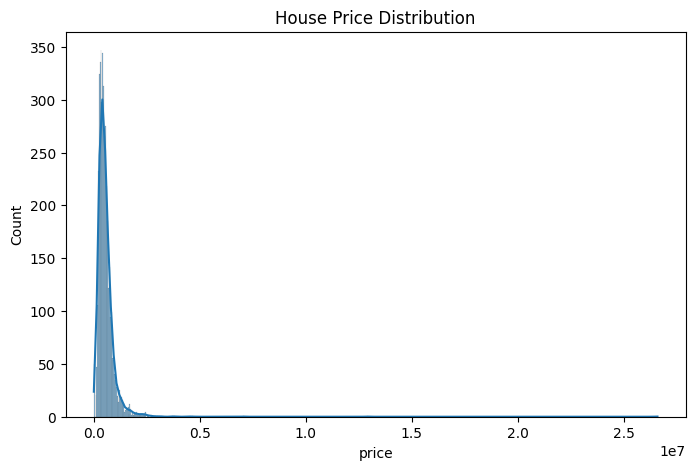

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title("House Price Distribution")
plt.show()

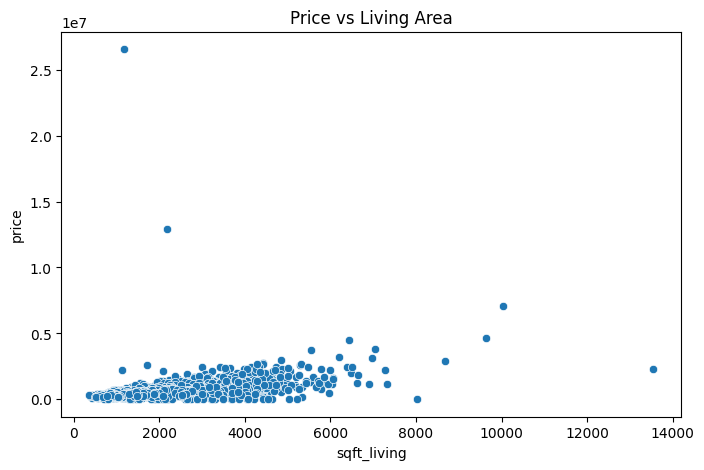

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="sqft_living",
    y="price",
    data=df
)

plt.title("Price vs Living Area")

plt.show()

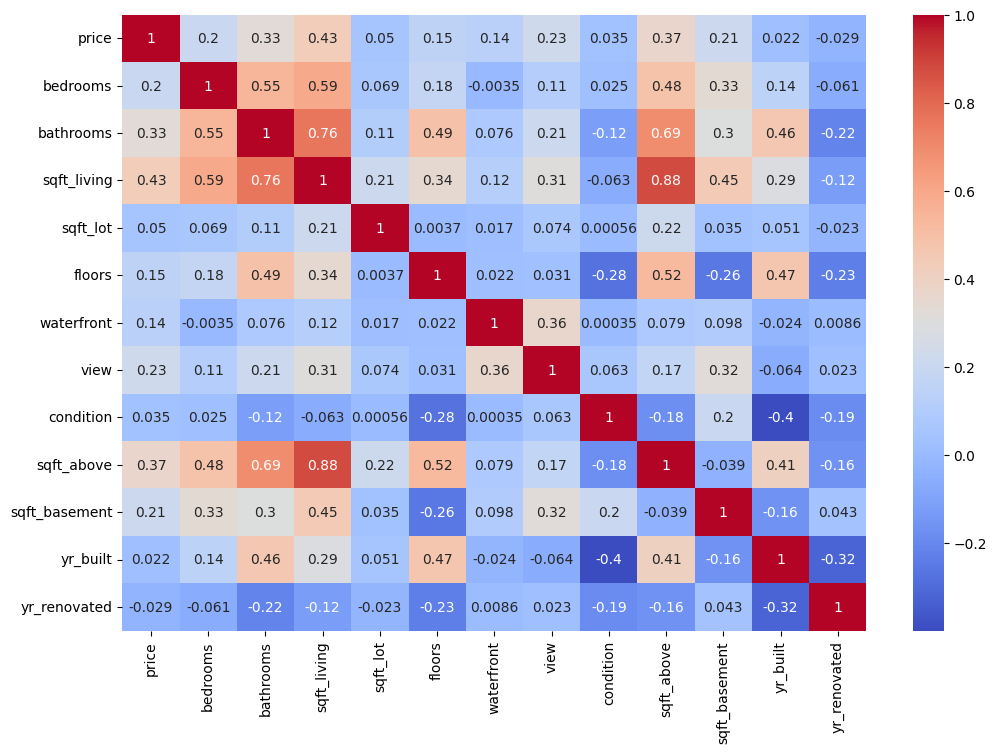

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [9]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df.drop("date", axis=1, inplace=True)
df.drop("street", axis=1, inplace=True)

In [10]:
for col in df.columns:

    if df[col].dtype == "object":
        df[col].fillna(
            df[col].mode()[0],
            inplace=True
        )

    else:
        df[col].fillna(
            df[col].median(),
            inplace=True
        )

/tmp/ipykernel_6425/924646867.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(
/tmp/ipykernel_6425/924646867.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inp

In [11]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:

    df[col] = encoder.fit_transform(
        df[col]
    )

In [12]:
df["price"] = np.log1p(
    df["price"]
)

In [13]:
X = df.drop(
    "price",
    axis=1
)

y = df["price"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [16]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(
    X_test
)

In [17]:
rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

In [18]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(
    X_test
)

In [19]:
def evaluate_model(
    name,
    y_true,
    pred
):

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    print(name)

    print("MAE :", mae)

    print("RMSE :", rmse)

    print("R2 Score :", r2)

    print("-"*40)

In [20]:
evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred
)

Linear Regression
MAE : 0.4682120922084041
RMSE : 1.383485590766467
R2 Score : 0.023526626410198648
----------------------------------------
Random Forest
MAE : 0.4612247804977322
RMSE : 1.4298572446074593
R2 Score : -0.04302924422803889
----------------------------------------
Gradient Boosting
MAE : 0.46650662585706076
RMSE : 1.46738576871979
R2 Score : -0.09849916357567534
----------------------------------------


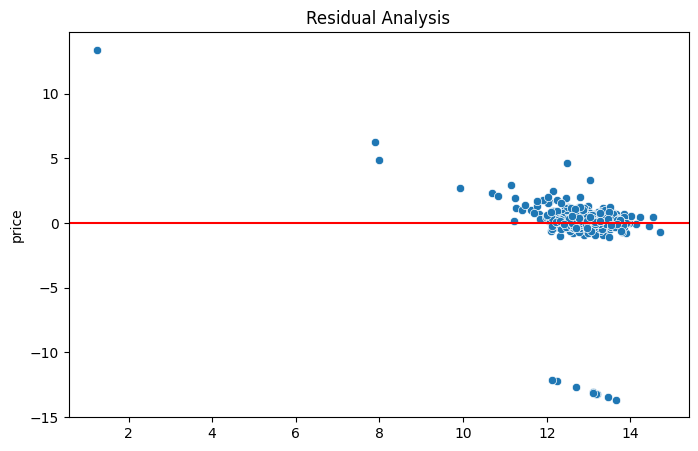

In [21]:
residuals = y_test - gb_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=gb_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red'
)

plt.title(
    "Residual Analysis"
)

plt.show()

In [22]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    gb_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
8,sqft_above,0.209893
2,sqft_living,0.146595
3,sqft_lot,0.104302
13,statezip,0.101656
1,bathrooms,0.081615
10,yr_built,0.074039
0,bedrooms,0.066419
12,city,0.065612
6,view,0.037473
9,sqft_basement,0.034006


In [23]:
joblib.dump(
    gb_model,
    "house_price_model.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [24]:
joblib.dump(
    scaler,
    "house_scaler.pkl"
)

['house_scaler.pkl']

In [25]:
model = joblib.load(
    "house_price_model.pkl"
)

sample = X.iloc[[0]]

sample_scaled = scaler.transform(
    sample
)

prediction = model.predict(
    sample_scaled
)

predicted_price = np.expm1(
    prediction
)

print(
    "Predicted House Price:",
    round(
        predicted_price[0],
        2
    )
)

Predicted House Price: 320133.38


In [26]:
from google.colab import files

files.download(
    "house_price_model.pkl"
)

files.download(
    "house_scaler.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>